<a href="https://colab.research.google.com/github/amina-la99/ML/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




**Data Manipulation**



In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/complex_simulated_faers.csv")


counts = df['side_effect_severity'].value_counts()
print("Avant équilibrage :", counts)

# Sépare chaque classe
dfs = [df[df['side_effect_severity'] == c] for c in range(4)]
min_count = min(len(d) for d in dfs)  # Nombre minimal dans les classes


dfs_balanced = [d.sample(min_count, random_state=42) for d in dfs]
df_balanced = pd.concat(dfs_balanced).sample(frac=1, random_state=42)  # Mélange tout


df_balanced




Avant équilibrage : side_effect_severity
0    4870
1    2639
2    1722
3     770
Name: count, dtype: int64


,patient_id,day,medication,symptom_headache,symptom_fever,symptom_nausea,symptom_dizziness,symptom_rash,symptom_fatigue,symptom_insomnia,side_effect_severity
4711,471,1,Atorvastatin,0,0,0,0,0,0,0,0
2811,281,1,Atorvastatin,0,0,0,0,0,0,0,2
1415,141,5,Levothyroxine,1,0,1,0,0,0,0,2
9358,935,8,Amoxicillin,0,0,0,0,0,1,0,0
5064,506,4,Metformin+Omeprazole,0,0,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
396,39,6,Warfarin,0,0,0,1,1,1,0,2
333,33,3,Simvastatin,1,0,0,0,0,0,1,1
7678,767,8,Salbutamol,0,0,0,1,1,0,0,1
2042,204,2,Levothyroxine,0,0,0,1,0,0,0,1


In [ ]:
# One-hot encoding des médicaments
df_balanced = pd.get_dummies(df_balanced, columns=['medication'])

# Définir les colonnes de features
feature_cols = [col for col in df_balanced.columns if col not in ['patient_id', 'day', 'side_effect_severity']]
print("Colonnes de features :", feature_cols)


Colonnes de features : ['symptom_headache', 'symptom_fever', 'symptom_nausea', 'symptom_dizziness', 'symptom_rash', 'symptom_fatigue', 'symptom_insomnia', 'medication_Amoxicillin', 'medication_Amoxicillin+Aspirin', 'medication_Amoxicillin+Ibuprofen', 'medication_Amoxicillin+Levothyroxine', 'medication_Amoxicillin+Losartan', 'medication_Amoxicillin+Metformin', 'medication_Amoxicillin+Paracetamol', 'medication_Amoxicillin+Simvastatin', 'medication_Amoxicillin+Warfarin', 'medication_Aspirin', 'medication_Aspirin+Amoxicillin', 'medication_Aspirin+Atorvastatin', 'medication_Aspirin+Levothyroxine', 'medication_Aspirin+Losartan', 'medication_Aspirin+Metformin', 'medication_Aspirin+Omeprazole', 'medication_Aspirin+Paracetamol', 'medication_Aspirin+Salbutamol', 'medication_Aspirin+Simvastatin', 'medication_Aspirin+Warfarin', 'medication_Atorvastatin', 'medication_Atorvastatin+Aspirin', 'medication_Atorvastatin+Ibuprofen', 'medication_Atorvastatin+Levothyroxine', 'medication_Atorvastatin+Losarta

3 Regroupement en séquences (patients)



In [ ]:
max_days = 10
sequences, labels = [], []


patient_ids = df_balanced['patient_id'].unique()

for pid in patient_ids:
    p = df_balanced[df_balanced['patient_id'] == pid].sort_values('day')
    feats = p[feature_cols].values
    lbls = p['side_effect_severity'].values

    if len(feats) < max_days:
        feats = np.pad(feats, ((0, max_days - len(feats)), (0, 0)), 'constant')
        lbls = np.pad(lbls, (0, max_days - len(lbls)), 'constant', constant_values=0)

    elif len(feats) > max_days:
        feats = feats[:max_days]
        lbls = lbls[:max_days]
    sequences.append(feats)
    labels.append(lbls)

X = np.array(sequences)
y = np.array(labels)
print("Shape X :", X.shape, "Shape y :", y.shape)

Shape X : (977, 10, 135) Shape y : (977, 10)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = 4  # 0=none, 1=mild, 2=moderate, 3=severe
y_cat = to_categorical(y, num_classes=num_classes)
print("Shape y_cat :", y_cat.shape)


Shape y_cat : (977, 10, 4)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42)

print("Train shape :", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)





Train shape : (781, 10, 135) (781, 10, 4)
Test shape : (196, 10, 135) (196, 10, 4)


In [ ]:
from collections import Counter
import numpy as np

#  Augmenter la sensibilité sur les cas les plus importants
def oversample_sequences(X, y, severe_thr=2, factor=4):
    X_aug, y_aug = list(X), list(y)
    for xi, yi in zip(X, y):
        if (yi >= severe_thr).sum() > 0:
            for _ in range(factor-1):
                X_aug.append(xi)
                y_aug.append(yi)
    return np.array(X_aug), np.array(y_aug)


X_os, y_os = oversample_sequences(X_train, y_train.argmax(axis=-1), severe_thr=2, factor=4)
y_os_cat = to_categorical(y_os, num_classes=4).astype(np.float32)

print("Nouvelle taille train :", X_os.shape, y_os_cat.shape)


Nouvelle taille train : (2734, 10, 135) (2734, 10, 4)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.4),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    TimeDistributed(Dense(num_classes, activation='softmax'))
])









/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import tensorflow as tf
#j'ai utiliser focal loss prsq ma base de données est difficile a classée surtt pour les deux clases severe et moderate
def categorical_focal_loss(alpha, gamma=2.0):
    """
    alpha: poids par classe (ex: [1, 1, 3, 10] pour booster Severe)
    gamma: “focalisation” (2 par défaut, plus c’est grand, plus la penalisation des erreurs rares est forte)
    """
    alpha = tf.constant(alpha, dtype=tf.float32)
    def loss(y_true, y_pred):
        # y_true et y_pred shape (batch, jours, classes)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weights = alpha * tf.math.pow(1 - y_pred, gamma)
        loss = weights * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return loss


In [ ]:
# Adapte le poids par classe (ici pour 4 classes)  Poids plus élevés pour classes “Moderate”/“Severe” et gamma pour se concentrer sur les erreurs rares
alpha = [1, 3, 6, 6]  # [None, Mild, Moderate, Severe]
model.compile(optimizer='adam', loss=categorical_focal_loss(alpha=alpha, gamma=1.5), metrics=['accuracy'])





In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_os, y_os_cat,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)



Epoch 1/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.6884 - loss: 1.5554 - val_accuracy: 0.6832 - val_loss: 1.1791
Epoch 2/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6945 - loss: 1.2113 - val_accuracy: 0.7296 - val_loss: 1.0556
Epoch 3/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.7428 - loss: 1.0912 - val_accuracy: 0.7541 - val_loss: 1.0006
Epoch 4/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7581 - loss: 1.0415 - val_accuracy: 0.7536 - val_loss: 0.9937
Epoch 5/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7606 - loss: 1.0141 - val_accuracy: 0.7617 - val_loss: 0.9998
Epoch 6/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7740 - loss: 0.9795 - val_accuracy: 0.7602 - val_loss: 1.0076
Epoch 7/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7737 - loss: 0.9794 - val_accuracy: 0.7673 - val_loss: 1.0196
Epoch 8/40
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7828 - loss: 0.9393 - val_accuracy: 0.7699 - v

**Evaluation**

In [ ]:
from sklearn.metrics import classification_report

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=-1)
y_true = np.argmax(y_test, axis=-1)

# Précision par jour
for day in range(y_true.shape[1]):
    acc = np.mean(y_true[:, day] == y_pred[:, day])
    print(f"Jour {day+1} : Accuracy = {acc:.2f}")

print(classification_report(
    y_true.flatten(), y_pred.flatten(),
    target_names=["None", "Mild", "Moderate", "Severe"]))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Jour 1 : Accuracy = 0.27
Jour 2 : Accuracy = 0.35
Jour 3 : Accuracy = 0.51
Jour 4 : Accuracy = 0.71
Jour 5 : Accuracy = 0.82
Jour 6 : Accuracy = 0.96
Jour 7 : Accuracy = 0.98
Jour 8 : Accuracy = 1.00
Jour 9 : Accuracy = 1.00
Jour 10 : Accuracy = 1.00
              precision    recall  f1-score   support

        None       0.99      0.90      0.94      1470
        Mild       1.00      0.01      0.01       150
    Moderate       0.28      0.60      0.38       166
      Severe       0.28      0.44      0.34       174

    accuracy                           0.76      1960
   macro avg       0.64      0.48      0.42      1960
weighted avg       0.87      0.76      0.77      1960



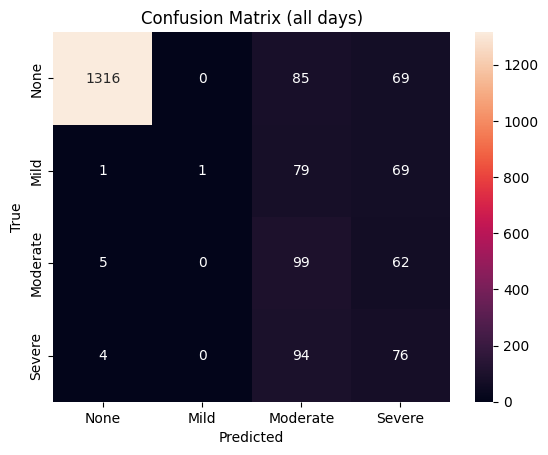

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true.flatten(), y_pred.flatten())
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["None", "Mild", "Moderate", "Severe"],
            yticklabels=["None", "Mild", "Moderate", "Severe"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (all days)")
plt.show()


In [ ]:
#ici juste pour comparer les valeurs de ma matrice de confusion pour voir si mon model il est entrain d'aprendre
import numpy as np
unique, counts = np.unique(y_true.flatten(), return_counts=True)
print(dict(zip(["None", "Mild", "Moderate", "Severe"], counts)))


{'None': np.int64(1470), 'Mild': np.int64(150), 'Moderate': np.int64(166), 'Severe': np.int64(174)}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


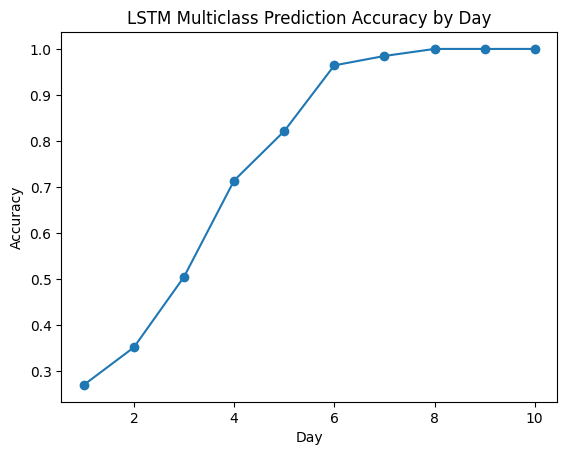

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Recalculate y_pred to ensure correct shape
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=-1)
y_true = np.argmax(y_test, axis=-1)

day_accuracies = [np.mean(y_true[:, day] == y_pred[:, day]) for day in range(y_true.shape[1])]
plt.plot(range(1, len(day_accuracies)+1), day_accuracies, marker='o')
plt.xlabel('Day')
plt.ylabel('Accuracy')
plt.title('LSTM Multiclass Prediction Accuracy by Day')
plt.show()

** NLP : Texte Patient -> Prédiction LSTM
**

In [ ]:
#  Les features utilisés à l'entraînement
feature_cols = [col for col in df_balanced.columns if col not in ['patient_id', 'day', 'side_effect_severity']]
med_cols = [col for col in feature_cols if col.startswith("medication_")]
symptom_cols = [col for col in feature_cols if col.startswith("symptom_")]

In [ ]:
# Mapping NLP (mots-clés simples)
SYMPTOM_KEYWORDS = {
    "symptom_headache": ["mal à la tête", "céphalée", "headache"],
    "symptom_fever": ["fièvre", "température", "fever"],
    "symptom_nausea": ["nausée", "envie de vomir", "nausea"],
    "symptom_dizziness": ["vertige", "tête qui tourne", "dizziness"],
    "symptom_rash": ["bouton", "allergie", "éruption", "rash"],
    "symptom_fatigue": ["fatigué", "fatigue", "épuisé", "fatigued"],
    "symptom_insomnia": ["insomnie", "mal dormir", "nuit blanche", "insomnia"]
}

In [ ]:
def text_to_features(text, feature_cols, med_cols, symptom_cols):
    text = text.lower()
    feats = {col: 0 for col in feature_cols}
    # Symptômes
    for col, keywords in SYMPTOM_KEYWORDS.items():
        if any(k in text for k in keywords):
            feats[col] = 1
    # Médicaments
    for col in med_cols:
        med_name = col.replace("medication_", "").replace("+", " ").lower()
        if med_name in text:
            feats[col] = 1
    return feats

In [ ]:
# (4) Construction de l'input pour le modèle LSTM
def build_model_input(text, all_feature_cols, med_cols, symptom_cols, n_days=10):
    feats = text_to_features(text, all_feature_cols, med_cols, symptom_cols)
    X_input = np.zeros((1, n_days, len(all_feature_cols)), dtype=np.float32)
    for i, col in enumerate(all_feature_cols):
        X_input[0, 0, i] = feats.get(col, 0) # Use .get to handle potential missing keys
    #dupliquation  sur tous les jours
    for j in range(1, n_days):
        X_input[0, j, :] = X_input[0, 0, :]
    return X_input

In [ ]:
# (5) Mapping des labels
label_map = ["None", "Mild", "Moderate", "Severe"]

# (6) Prédiction patient unique c'est modifiables pour plusieurs patients
def predict_patient_severity(text, feature_cols, med_cols, symptom_cols, n_days=10):
    feats = text_to_features(text, feature_cols, med_cols, symptom_cols)
    if sum([feats[c] for c in symptom_cols]) == 0:
        return "None"
    X_input = build_model_input(text, feature_cols, med_cols, symptom_cols, n_days)
    y_pred = model.predict(X_input)
    return label_map[np.argmax(y_pred[0, 0])]


In [ ]:
# (7) Exemple d'utilisation
texte_patient = "J'ai des vertiges, une grande fatigue, des nausées, de la fièvre, des boutons, je prends warfarin et amoxicillin"
X_input = build_model_input(texte_patient, feature_cols, med_cols, symptom_cols, n_days=10)
print("Shape X_input :", X_input.shape)  # Pour vérification
y_pred = model.predict(X_input)
print("Texte patient :", texte_patient)
print("Sévérité prédite (jour 1):", label_map[np.argmax(y_pred[0, 0])])

Shape X_input : (1, 10, 133)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Texte patient : J'ai des vertiges, une grande fatigue, des nausées, de la fièvre, des boutons, je prends warfarin et amoxicillin
Sévérité prédite (jour 1): Severe


Test Texts exemples

In [ ]:
#test_texts = [
    # Cas 1: Patient sans symptômes, médicament “doux”
#    "Je ne ressens aucun symptôme, je prends seulement paracetamol.",

    # Cas 2: Patient légèrement symptomatique, médicament courant
 #   "J'ai un peu mal à la tête et je prends ibuprofen.",

    # Cas 3: Plusieurs symptômes bénins, médicaments classiques
  #  "J'ai de la fièvre et des maux de tête, je prends aspirin et paracetamol.",

    # Cas 4: Un médicament à risque mais symptômes faibles
   # "Je prends warfarin mais je n'ai pas de symptôme particulier.",

    # Cas 5: Symptômes modérés, médicament intermédiaire
  #  "Depuis deux jours, je me sens fatigué et j'ai des vertiges. Je prends metformin.",

    # Cas 6: Plusieurs symptômes + médicaments “à risque”
  #  "J'ai une grande fatigue, des nausées et je prends amoxicillin et simvastatin.",

    # Cas 7: Patient avec tout : symptômes sévères + médocs forts
   # "Je vomis, j'ai de la fièvre, des boutons sur la peau, une grosse fatigue et je prends warfarin et amoxicillin.",

    # Cas 8: Cas insomnia, symptomatique sans médoc
   # "Je dors très mal, je me sens fatigué mais je ne prends aucun médicament.",

    # Cas 9: Patient mentionne plusieurs médicaments mais pas de symptômes
   # "Je prends aspirin et simvastatin mais je me sens bien.",

    # Cas 10: Patient décrit seulement des douleurs musculaires (non mappées)
    #"J'ai mal aux muscles et je me sens courbaturé, mais pas de fièvre ni nausée.",
#]

**Patient Interface**

In [ ]:

import gradio as gr
import pandas as pd
import os
import re

# --- FICHIERS ---
FICHIER_PATIENT = "patients_suivi.csv"

DATASET_PRINCIPAL = "/content/drive/MyDrive/Colab Notebooks/complex_simulated_faers.csv"

# --- COLONNES & SYMPTOMES (conformes au dataset) ---
DATASET_COLUMNS = [
    "patient_id", "day", "medication",
    "symptom_headache", "symptom_fever", "symptom_nausea",
    "symptom_dizziness", "symptom_rash", "symptom_fatigue",
    "symptom_insomnia", "side_effect_severity"
]
SYMPTOMS = ["headache", "fever", "nausea", "dizziness", "rash", "fatigue", "insomnia"]

def extract_symptoms(text: str):
    t = (text or "").lower()
    return {f"symptom_{s}": int(s in t) for s in SYMPTOMS}

def normalize_severity(pred):
    label_map = {"none": 0, "mild": 1, "moderate": 2, "severe": 3}
    if isinstance(pred, (int, float)) and int(pred) in (0,1,2,3):
        return int(pred)
    if isinstance(pred, str):
        p = pred.strip().lower()
        if p in label_map:
            return label_map[p]

        m = re.findall(r"\b([0-3])\b", p)
        if m:
            return int(m[-1])
    raise ValueError(f"Predicted severity must be 0..3; got: {pred!r}")

def to_int(x):
    """Cast robuste -> int (ex: '001' -> 1)."""
    return int(str(x).strip())

# --- SAUVEGARDES ---
def sauvegarder_donnees(patient_id, day, medication, texte_patient, pred):

    df = pd.DataFrame([{
        "patient_id": patient_id,
        "day": day,
        "medication": medication,
        "texte_patient": texte_patient,
        "predicted_severity": pred
    }])
    if not os.path.exists(FICHIER_PATIENT):
        df.to_csv(FICHIER_PATIENT, index=False)
    else:
        df.to_csv(FICHIER_PATIENT, mode='a', header=False, index=False)

#ici dans cette partie  Ajoute la donnée dans le dataset principal (complex_simulated_faers.csv)
def sauvegarder_dans_dataset_principal(patient_id, day, medication, texte_patient, pred):

    sev = normalize_severity(pred)
    sym = extract_symptoms(texte_patient)

    row = {
        "patient_id": to_int(patient_id),
        "day": to_int(day),
        "medication": str(medication) if medication is not None else "",
        **{k: int(v) for k, v in sym.items()},
        "side_effect_severity": int(sev)
    }

    # Réordonner/compléter exactement comme le dataset
    for col in DATASET_COLUMNS:
        row.setdefault(col, 0 if col.startswith("symptom_") or col in ("patient_id","day","side_effect_severity") else (row.get(col) if col=="medication" else ""))

    df2 = pd.DataFrame([[row[c] for c in DATASET_COLUMNS]], columns=DATASET_COLUMNS)


    int_cols = ["patient_id","day","side_effect_severity"] + [c for c in DATASET_COLUMNS if c.startswith("symptom_")]
    df2[int_cols] = df2[int_cols].astype(int)
    df2["medication"] = df2["medication"].astype(str)


    if not os.path.exists(DATASET_PRINCIPAL):
        df2.to_csv(DATASET_PRINCIPAL, index=False)
    else:
        df2.to_csv(DATASET_PRINCIPAL, mode='a', header=False, index=False)


def gradio_predict(texte_patient, patient_id, day, medication):
    pred = predict_patient_severity(texte_patient, feature_cols, med_cols, symptom_cols, n_days=10)
    # 1) suivi
    sauvegarder_donnees(patient_id, day, medication, texte_patient, pred)
    # 2) dataset principal strict
    sauvegarder_dans_dataset_principal(patient_id, day, medication, texte_patient, pred)
    sev_num = normalize_severity(pred)
    return f"Sévérité prédite (jour {day}): {sev_num}"

with gr.Blocks() as demo:
    gr.Markdown("# Saisie patient (suivi sur 10 jours)")
    patient_id = gr.Textbox(label="ID Patient (numérique, ex: 0,1,2)", value="0")
    day = gr.Slider(0, 10, value=1, step=1, label="Jour du suivi")
    medication = gr.Textbox(label="Médicament(s) pris", value="")
    texte_patient = gr.Textbox(lines=4, label="Description du patient (symptômes)")
    sortie = gr.Textbox(label="Résultat : 0: None , 1:Mild , 2:Moderate , 3:Severe ")
    bouton = gr.Button("Enregistrer et prédire")
    bouton.click(
        gradio_predict,
        inputs=[texte_patient, patient_id, day, medication],
        outputs=sortie
    )
demo.launch(debug=True)





It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://170e2ead2d15e578fe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://170e2ead2d15e578fe.gradio.live


**Like Server Side**

In [ ]:
#pour l'afficher arreter l'execution du l'interface patient
df = pd.read_csv("/content/patients_suivi.csv").fillna("None")
df

,patient_id,day,medication,texte_patient,predicted_severity
0,1,1,ibuprofen,J'ai un peu mal à la tête et je prends ibuprofen,Severe
1,1,1,ibuprofen,J'ai un peu mal à la tête et je prends ibuprofen,Severe
2,2,1,ibuprofen,J'ai un peu mal à la tête et je prends ibuprofen,Severe
3,1,1,"warfarin , amoxicillin","Je vomis, j'ai de la fièvre, des boutons sur l...",Moderate
4,5,1,metformin,"Depuis deux jours, je me sens fatigué et j'ai ...",Severe


In [ ]:
import gradio as gr
import pandas as pd
import os

FICHIER_PATIENT = "patients_suivi.csv"

def voir_historique(patient_id):
    if not os.path.exists(FICHIER_PATIENT):
        return pd.DataFrame([{"Message": "Aucune donnée disponible"}])
    df = pd.read_csv(FICHIER_PATIENT)
    df_patient = df[df['patient_id'] == patient_id].sort_values("day")
    if df_patient.empty:
        return pd.DataFrame([{"Message": "Aucune donnée pour ce patient"}])
    return df_patient

def get_patient_ids():
    if not os.path.exists(FICHIER_PATIENT):
        return []
    df = pd.read_csv(FICHIER_PATIENT)
    return df['patient_id'].unique().tolist()

demo_medecin = gr.Interface(
    fn=voir_historique,
    inputs=gr.Dropdown(choices=get_patient_ids(), label="Choisir ID patient"),
    outputs=gr.Dataframe(label="Historique du patient"),
    title="Suivi Patient (interface médecin)",
    description="Affiche le suivi sur 10 jours de chaque patient."
)
demo_medecin.launch(debug=True)



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://96fe75a25b49a76649.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://96fe75a25b49a76649.gradio.live
